# OncoBridge-MMCAT — Drug Response Fine-Tuning v4
## ChemBERTa Drug Encoder · Modality Dropout · Stratified Splits · Per-Drug PCC · Drug Cold-Start

### Architecture:
```
mRNA + CNV + Mut + Meth
        ↓
OncoBridgeMMCAT_v7 backbone (FROZEN encoders)
        ↓
1920-dim patient fingerprint
                          Drug SMILES string
                                  ↓
                          ChemBERTa (frozen pretrained)
                          → 384-dim CLS embedding
                          → Projection MLP 384→256
        ↓                         ↓
Concat [patient | drug_emb] → 2176-dim
        ↓
Regression Head → LN_IC50
```

### Changes over v3:
| # | Change | Why |
|---|--------|-----|
| 1 | **ChemBERTa drug encoder** replaces Morgan FP MLP | Pretrained SMILES transformer captures molecular structure far better than bit hashing. Critical for cold-start. |
| 2 | **Modality Dropout p=0.20** during training | v3 ablation proved mutations contribute 0.0006 PCC — model ignored them. Dropout forces all 4 modalities to be learned. |
| 3 | **Stage 2 unfreezes only last 2 cross-layers** | v3 unfroze all 4 = 28M params for 5,442 training pairs. Severe overparameterization. Last 2 = 14M — better fit. |
| 4 | **Fixed Cell 13 bug**: `mean_true_ic50=('ic50_value','mean')` | v3 computed ground-truth mean from PRED_IC50 — both columns were identical. |
| 5 | **Updated PyTorch AMP API** | `torch.cuda.amp.autocast` deprecated in PyTorch 2.x. Updated to `torch.amp.autocast('cuda')`. |
| 6 | **Metrics aligned to published papers** | Global PCC, Spearman, R², RMSE, AUROC — same as DeepCDR, DRN-CDR, DTLCDR, PASO. AvgDrugPCC kept as supplementary diagnostic only. |


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — IMPORTS, SETUP & CONFIG
# ═══════════════════════════════════════════════════════════════════════
import os, gc, json, math, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score

# ChemBERTa — install if not present
try:
    from transformers import AutoTokenizer, AutoModel
    print('transformers already installed')
except ImportError:
    os.system('pip install transformers -q')
    from transformers import AutoTokenizer, AutoModel

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_theme(style='whitegrid')

def section(t):
    print('\n' + '═'*70)
    print(f'  {t}')
    print('═'*70)

# ── Device ──────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f'Device: {DEVICE} | GPUs: {N_GPUS}')
for i in range(N_GPUS):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)} | '
          f'{torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')

# ── PATHS ────────────────────────────────────────────────────────────────
DATA_BASE = '/kaggle/input/smiles-data'
CKPT_PATH = '/kaggle/input/models/proutkarshtiwari/oncobridgev7-95-74acc/pytorch/default/1/oncobridge_v7_best.pt'
OUT_DIR   = '/kaggle/working/'

PATH_MRNA        = f'{DATA_BASE}/ccle_mrna_scaled.parquet'
PATH_CNV         = f'{DATA_BASE}/ccle_cnv_scaled.parquet'
PATH_MUT         = f'{DATA_BASE}/ccle_mut_scaled.parquet'
PATH_METH        = f'{DATA_BASE}/ccle_meth_scaled.parquet'
PATH_IC50_WARM   = f'{DATA_BASE}/ic50_warm.parquet'
PATH_IC50_COLD   = f'{DATA_BASE}/ic50_cold.parquet'
PATH_SPLITS      = f'{DATA_BASE}/ccle_splits.json'
PATH_FP_MATRIX   = f'{DATA_BASE}/drug_fp_matrix.npy'
PATH_DRUG_NAMES  = f'{DATA_BASE}/valid_drug_names.csv'
PATH_COLD_DRUGS  = f'{DATA_BASE}/cold_start_drugs.json'
PATH_SMILES      = f'{DATA_BASE}/drug_smiles_cache.csv'

# ── CONFIG ────────────────────────────────────────────────────────────────
CONFIG = {
    'num_mrna_genes': 8011,
    'num_cnv_genes':  3500,
    'num_mut_genes':  2500,
    'num_meth_genes': 6000,
    'embed_dim':          384,
    'num_heads':          8,
    'num_encoder_layers': 6,
    'num_cross_layers':   4,
    'cnn_kernel':         16,
    'cnn_stride':         16,
    'ff_dim':             1536,
    'dropout':            0.20,
    'gate_init':          1.5,
    'use_grad_ckpt':      False,
    'num_classes':        22,
    'chemberta_model':  'seyonec/ChemBERTa-zinc-base-v1',
    'chemberta_dim':    768,
    'drug_embed_dim':   256,
    'drug_proj_hidden': 384,
    'drug_proj_dropout':0.2,
    'modality_dropout_p': 0.20,
    'batch_size':    64,
    'grad_accum':    4,
    'num_workers':   4,
    'use_amp':       True,
    'clip_grad':     1.0,
    'warmup_frac':   0.15,
    'stage1_epochs':   30,
    'stage1_lr':       1e-3,
    'stage1_wd':       1e-4,
    'stage1_patience': 8,
    'stage2_unfreeze_n_cross': 2,
    'stage2_epochs':     40,
    'stage2_lr_head':    1e-4,
    'stage2_lr_cross':   5e-5,
    'stage2_wd':         1e-4,
    'stage2_patience':   10,
    'checkpoint_ft': 'oncobridge_drug_response_v4_best.pt',
}

eff_batch = CONFIG['batch_size'] * CONFIG['grad_accum']
print(f'\nOncoBridge v4')
print(f'Effective batch: {CONFIG["batch_size"]} x {CONFIG["grad_accum"]} = {eff_batch}')
print(f'Drug encoder: ChemBERTa ({CONFIG["chemberta_model"]}) -> {CONFIG["drug_embed_dim"]}-dim')
print(f'Modality dropout: p={CONFIG["modality_dropout_p"]}')
print(f'Stage 2 unfreezes last {CONFIG["stage2_unfreeze_n_cross"]} cross-layers (v3 unfroze all 4)')

transformers already installed
Device: cuda | GPUs: 2
  GPU 0: Tesla T4 | 15.6 GB
  GPU 1: Tesla T4 | 15.6 GB

OncoBridge v4
Effective batch: 64 x 4 = 256
Drug encoder: ChemBERTa (seyonec/ChemBERTa-zinc-base-v1) -> 256-dim
Modality dropout: p=0.2
Stage 2 unfreezes last 2 cross-layers (v3 unfroze all 4)


In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — LOAD PROCESSED DATA
# ═══════════════════════════════════════════════════════════════════════
section('2. LOAD DATA')

t0 = time.time()
mrna_df   = pd.read_parquet(PATH_MRNA)
cnv_df    = pd.read_parquet(PATH_CNV)
mut_df    = pd.read_parquet(PATH_MUT)
meth_df   = pd.read_parquet(PATH_METH)
ic50_warm = pd.read_parquet(PATH_IC50_WARM)
ic50_cold = pd.read_parquet(PATH_IC50_COLD)
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'mRNA {mrna_df.shape} | CNV {cnv_df.shape} | Mut {mut_df.shape} | Meth {meth_df.shape}')
print(f'IC50 warm: {len(ic50_warm):,} | cold: {len(ic50_cold):,}')

with open(PATH_SPLITS) as f: splits = json.load(f)
cl_train = splits['train']; cl_val = splits['val']; cl_test = splits['test']
print(f'Cell lines: Train={len(cl_train)} Val={len(cl_val)} Test={len(cl_test)}')

FP_MATRIX  = np.load(PATH_FP_MATRIX).astype(np.float32)
DRUG_NAMES = pd.read_csv(PATH_DRUG_NAMES, header=None)[0].tolist()
drug2idx   = {d: i for i, d in enumerate(DRUG_NAMES)}
id_to_drug = {i: d for d, i in drug2idx.items()}
n_drugs    = len(DRUG_NAMES)
print(f'Drugs: {n_drugs} | FP_MATRIX: {FP_MATRIX.shape}')

# CHANGE 1: Load SMILES lookup for ChemBERTa
smiles_df   = pd.read_csv(PATH_SMILES)
drug2smiles = dict(zip(smiles_df['drug_name'], smiles_df['smiles']))  # lowercase
SMILES_LIST = [drug2smiles.get(d, 'C') for d in DRUG_NAMES]
n_missing = sum(1 for s in SMILES_LIST if s == 'C')
print(f'SMILES loaded: {len(SMILES_LIST) - n_missing}/{len(SMILES_LIST)} drugs have SMILES')

with open(PATH_COLD_DRUGS) as f: cold_info = json.load(f)
cold_start_drugs = set(cold_info['cold_start'])

all_cell_lines = sorted(mrna_df.index.tolist())
cl_to_idx = {cl: i for i, cl in enumerate(all_cell_lines)}

for df in [ic50_warm, ic50_cold]:
    df['cl_idx']   = df['ModelID'].map(cl_to_idx)
    df['drug_idx'] = df['DRUG_NAME'].map(drug2idx)

ic50_warm = ic50_warm.dropna(subset=['cl_idx','drug_idx'])
ic50_warm['cl_idx']   = ic50_warm['cl_idx'].astype(int)
ic50_warm['drug_idx'] = ic50_warm['drug_idx'].astype(int)

ic50_cold = ic50_cold.dropna(subset=['cl_idx','drug_idx'])
ic50_cold['cl_idx']   = ic50_cold['cl_idx'].astype(int)
ic50_cold['drug_idx'] = ic50_cold['drug_idx'].astype(int)

print('\nPre-stacking omics...')
mrna_arr = mrna_df.loc[all_cell_lines].values.astype(np.float32)
cnv_arr  = cnv_df.loc[all_cell_lines].values.astype(np.float32)
mut_arr  = mut_df.loc[all_cell_lines].values.astype(np.float32)
meth_arr = meth_df.loc[all_cell_lines].values.astype(np.float32)

total_mb = (mrna_arr.nbytes+cnv_arr.nbytes+mut_arr.nbytes+meth_arr.nbytes) / 1e6
print(f'Omics RAM: {total_mb:.0f} MB')
del mrna_df, cnv_df, mut_df, meth_df; gc.collect()


══════════════════════════════════════════════════════════════════════
  2. LOAD DATA
══════════════════════════════════════════════════════════════════════
Loaded in 2.1s
mRNA (381, 8011) | CNV (381, 3500) | Mut (381, 2500) | Meth (381, 6000)
IC50 warm: 7,902 | cold: 1,441
Cell lines: Train=266 Val=38 Test=77
Drugs: 58 | FP_MATRIX: (58, 2048)
SMILES loaded: 58/58 drugs have SMILES

Pre-stacking omics...
Omics RAM: 30 MB


116

In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2b — PRE-COMPUTE ChemBERTa EMBEDDINGS
# ═══════════════════════════════════════════════════════════════════════
section('2b. PRE-COMPUTE ChemBERTa DRUG EMBEDDINGS')

print(f'Loading ChemBERTa: {CONFIG["chemberta_model"]} ...')
t0 = time.time()

cb_tokenizer = AutoTokenizer.from_pretrained(CONFIG['chemberta_model'])
cb_model     = AutoModel.from_pretrained(CONFIG['chemberta_model'])
cb_model     = cb_model.to(DEVICE)
cb_model.eval()
for p in cb_model.parameters(): p.requires_grad = False
print(f'ChemBERTa loaded in {time.time()-t0:.1f}s  |  '
      f'Params: {sum(p.numel() for p in cb_model.parameters()):,} (all frozen)')

def get_chemberta_embeddings(smiles_list, tokenizer, model, batch_size=32):
    """Convert a list of SMILES strings to ChemBERTa CLS embeddings.
    Returns: numpy array (n_drugs, 384)"""
    all_embs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(smiles_list), batch_size):
            batch_smiles = smiles_list[i:i+batch_size]
            enc = tokenizer(
                batch_smiles,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors='pt'
            )
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = model(**enc)
            cls = out.last_hidden_state[:, 0, :]
            all_embs.append(cls.cpu().float().numpy())
    return np.concatenate(all_embs, axis=0)

print(f'Computing ChemBERTa embeddings for {n_drugs} drugs...')
t1 = time.time()
DRUG_EMB_MATRIX = get_chemberta_embeddings(
    SMILES_LIST, cb_tokenizer, cb_model, batch_size=32
)
print(f'Done in {time.time()-t1:.1f}s  |  '
      f'Shape: {DRUG_EMB_MATRIX.shape}  |  '
      f'RAM: {DRUG_EMB_MATRIX.nbytes/1e6:.1f} MB')

del cb_model; gc.collect(); torch.cuda.empty_cache()
print('ChemBERTa model freed from GPU memory.')

cos_sim_01 = np.dot(DRUG_EMB_MATRIX[0], DRUG_EMB_MATRIX[1]) / (
    np.linalg.norm(DRUG_EMB_MATRIX[0]) * np.linalg.norm(DRUG_EMB_MATRIX[1]))
print(f'Sanity check — cosine sim drug[0] vs drug[1]: {cos_sim_01:.4f} (should be < 1.0)')


══════════════════════════════════════════════════════════════════════
  2b. PRE-COMPUTE ChemBERTa DRUG EMBEDDINGS
══════════════════════════════════════════════════════════════════════
Loading ChemBERTa: seyonec/ChemBERTa-zinc-base-v1 ...


config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/179M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

ChemBERTa loaded in 6.5s  |  Params: 44,103,936 (all frozen)
Computing ChemBERTa embeddings for 58 drugs...
Done in 1.3s  |  Shape: (58, 768)  |  RAM: 0.2 MB
ChemBERTa model freed from GPU memory.
Sanity check — cosine sim drug[0] vs drug[1]: 0.8272 (should be < 1.0)


In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 3 — DATASET & DATALOADERS
# ═══════════════════════════════════════════════════════════════════════
section('3. DATASET')

class DrugResponseDataset(Dataset):
    """Each sample = (cell_line, drug) -> LN_IC50.
    v4: drug represented by pre-computed ChemBERTa CLS embedding (384-dim)."""
    def __init__(self, ic50_df, cell_lines, mrna_arr, cnv_arr, mut_arr, meth_arr,
                 drug_emb_matrix):
        cl_set = set(cell_lines)
        sub = ic50_df[ic50_df['ModelID'].isin(cl_set)].reset_index(drop=True)
        self.cl_idx        = sub['cl_idx'].values.astype(np.int32)
        self.drug_idx      = sub['drug_idx'].values.astype(np.int64)
        self.ic50          = sub['ic50_value'].values.astype(np.float32)
        self.mrna_arr      = mrna_arr
        self.cnv_arr       = cnv_arr
        self.mut_arr       = mut_arr
        self.meth_arr      = meth_arr
        self.drug_emb_mat  = drug_emb_matrix

    def __len__(self): return len(self.ic50)

    def __getitem__(self, idx):
        ci  = self.cl_idx[idx]
        did = self.drug_idx[idx]
        return (
            torch.from_numpy(self.mrna_arr[ci]),
            torch.from_numpy(self.cnv_arr[ci]),
            torch.from_numpy(self.mut_arr[ci]),
            torch.from_numpy(self.meth_arr[ci]),
            torch.from_numpy(self.drug_emb_mat[did]),
            torch.tensor(self.ic50[idx]),
            torch.tensor(did),
        )

train_ds = DrugResponseDataset(ic50_warm, cl_train,       mrna_arr, cnv_arr, mut_arr, meth_arr, DRUG_EMB_MATRIX)
val_ds   = DrugResponseDataset(ic50_warm, cl_val,         mrna_arr, cnv_arr, mut_arr, meth_arr, DRUG_EMB_MATRIX)
test_ds  = DrugResponseDataset(ic50_warm, cl_test,        mrna_arr, cnv_arr, mut_arr, meth_arr, DRUG_EMB_MATRIX)
cold_ds  = DrugResponseDataset(ic50_cold, all_cell_lines, mrna_arr, cnv_arr, mut_arr, meth_arr, DRUG_EMB_MATRIX)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,} | Cold: {len(cold_ds):,}')

nw = CONFIG['num_workers']
def make_loader(ds, shuffle, bs_mult=1):
    return DataLoader(ds, batch_size=CONFIG['batch_size']*bs_mult,
                      shuffle=shuffle, num_workers=nw,
                      pin_memory=True, persistent_workers=(nw>0),
                      prefetch_factor=2 if nw>0 else None,
                      drop_last=shuffle)

train_loader = make_loader(train_ds, True)
val_loader   = make_loader(val_ds,   False, 2)
test_loader  = make_loader(test_ds,  False, 2)
cold_loader  = make_loader(cold_ds,  False, 2)

b = next(iter(train_loader))
mrna_b, cnv_b, mut_b, meth_b, drug_emb_b, ic50_b, drug_b = b
print(f'Batch: mRNA={mrna_b.shape} | DrugEmb={drug_emb_b.shape} | IC50 range [{ic50_b.min():.2f},{ic50_b.max():.2f}]')
print(f'DrugEmb dim: {drug_emb_b.shape[1]} (ChemBERTa CLS, was 2048 Morgan FP in v3)')


══════════════════════════════════════════════════════════════════════
  3. DATASET
══════════════════════════════════════════════════════════════════════
Train: 5,442 | Val: 764 | Test: 1,696 | Cold: 1,441
Batch: mRNA=torch.Size([64, 8011]) | DrugEmb=torch.Size([64, 768]) | IC50 range [-6.52,4.48]
DrugEmb dim: 768 (ChemBERTa CLS, was 2048 Morgan FP in v3)


In [5]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — MODEL ARCHITECTURE
# ═══════════════════════════════════════════════════════════════════════
section('4. ARCHITECTURE')

# ── Phase 1 backbone classes — DO NOT MODIFY ────────────────────────────

class GeneImportanceLayer(nn.Module):
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), init_val))
    def forward(self, x):
        return x * torch.sigmoid(self.logits)

class ModalityEncoder(nn.Module):
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout,
                 gate_init=1.5, use_ckpt=False):
        super().__init__()
        self.use_ckpt   = use_ckpt
        self.gene_gate  = GeneImportanceLayer(num_genes, init_val=gate_init)
        self.input_proj = nn.Linear(1, embed_dim)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim,
                      kernel_size=cnn_kernel, stride=cnn_stride,
                      padding=cnn_kernel//2),
            nn.GELU(), nn.BatchNorm1d(embed_dim))
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim)*0.02)
        compressed = (num_genes + cnn_kernel//2*2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb = nn.Parameter(torch.randn(1, compressed, embed_dim)*0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
    def _tfm(self, x): return self.transformer(x)
    def forward(self, x):
        x = self.gene_gate(x).unsqueeze(-1)
        x = self.input_proj(x).transpose(1,2)
        x = self.cnn(x).transpose(1,2)
        B = x.size(0)
        cls = self.cls_token.expand(B,-1,-1)
        x = torch.cat([cls, x], dim=1) + self.pos_emb[:,:x.size(1)+1,:]
        x = grad_checkpoint(self._tfm, x, use_reentrant=False) if self.use_ckpt and self.training else self._tfm(x)
        return self.norm(x)

class CrossModalAttention4(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        mods = ['mrna','cnv','mut','meth']
        self.cross_attns = nn.ModuleDict({m: nn.MultiheadAttention(embed_dim, num_heads,
                                          dropout=dropout, batch_first=True) for m in mods})
        self.q_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
        def ffn(): return nn.Sequential(nn.Linear(embed_dim,ff_dim),nn.GELU(),
                                        nn.Dropout(dropout),nn.Linear(ff_dim,embed_dim),
                                        nn.Dropout(dropout))
        self.ffns      = nn.ModuleDict({m: ffn() for m in mods})
        self.ffn_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
    def forward(self, mrna_seq, cnv_seq, mut_seq, meth_seq):
        seqs = {'mrna':mrna_seq,'cnv':cnv_seq,'mut':mut_seq,'meth':meth_seq}
        out  = {}
        for m, q_seq in seqs.items():
            others = torch.cat([s for k,s in seqs.items() if k!=m], dim=1)
            q = self.q_norms[m](q_seq)
            h,_ = self.cross_attns[m](q, others, others, need_weights=False)
            ao = q_seq + h
            out[m] = ao + self.ffns[m](self.ffn_norms[m](ao))
        return out['mrna'], out['cnv'], out['mut'], out['meth']

class GatedFusion4(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.gate = nn.Linear(embed_dim*4, 4)
    def forward(self, m, c, u, e):
        g = F.softmax(self.gate(torch.cat([m,c,u,e], dim=-1)), dim=-1)
        fused = g[:,0:1]*m + g[:,1:2]*c + g[:,2:3]*u + g[:,3:4]*e
        return fused, g

class OncoBridgeMMCAT_v7(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        E,H,NL,NC = cfg['embed_dim'],cfg['num_heads'],cfg['num_encoder_layers'],cfg['num_cross_layers']
        K,S,FF,D  = cfg['cnn_kernel'],cfg['cnn_stride'],cfg['ff_dim'],cfg['dropout']
        GI,UC     = cfg['gate_init'],cfg['use_grad_ckpt']
        self.mrna_enc    = ModalityEncoder(cfg['num_mrna_genes'],E,H,NL,K,S,FF,D,GI,UC)
        self.cnv_enc     = ModalityEncoder(cfg['num_cnv_genes'], E,H,NL,K,S,FF,D,GI,UC)
        self.mut_enc     = ModalityEncoder(cfg['num_mut_genes'], E,H,NL,K,S,FF,D,GI,UC)
        self.meth_enc    = ModalityEncoder(cfg['num_meth_genes'],E,H,NL,K,S,FF,D,GI,UC)
        self.cross_layers= nn.ModuleList([CrossModalAttention4(E,H,FF,D) for _ in range(NC)])
        self.fusion      = GatedFusion4(E)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(E*5), nn.Linear(E*5,E*2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E*2,E),  nn.GELU(), nn.Dropout(D), nn.Linear(E,cfg['num_classes']))
    def forward(self, mrna, cnv, mut, meth):
        ms=self.mrna_enc(mrna); cs=self.cnv_enc(cnv)
        us=self.mut_enc(mut);   es=self.meth_enc(meth)
        for layer in self.cross_layers:
            ms,cs,us,es = layer(ms,cs,us,es)
        cm=ms[:,0]; cc=cs[:,0]; cu=us[:,0]; ce=es[:,0]
        fused, gates = self.fusion(cm,cc,cu,ce)
        return self.classifier(torch.cat([cm,cc,cu,ce,fused], dim=-1))


# ── CHANGE 1: ChemBERTa Projection Encoder ──────────────────────────────
class ChemBERTaProjectionEncoder(nn.Module):
    """Projects pre-computed ChemBERTa CLS embeddings (384-dim) to
    drug_embed_dim (256) via a 2-layer MLP.
    (B, 384) -> BN -> Linear(384->384) -> GELU -> Dropout -> Linear(384->256) -> LayerNorm"""
    def __init__(self, chemberta_dim=384, hidden=384, out_dim=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(chemberta_dim),
            nn.Linear(chemberta_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
            nn.LayerNorm(out_dim),
        )
    def forward(self, emb):
        return self.net(emb)


# ── CHANGE 1+2: DrugResponseModel_v4 ────────────────────────────────────
class DrugResponseModel_v4(nn.Module):
    """v4 changes: ChemBERTaProjectionEncoder + Modality Dropout."""
    def __init__(self, base_model, chemberta_dim, drug_proj_hidden,
                 drug_embed_dim, drug_proj_dropout,
                 modality_dropout_p, backbone_dropout=0.3):
        super().__init__()
        self.base_model         = base_model
        self.modality_dropout_p = modality_dropout_p

        E            = 384
        patient_dim  = E * 5
        combined_dim = patient_dim + drug_embed_dim

        self.drug_encoder = ChemBERTaProjectionEncoder(
            chemberta_dim, drug_proj_hidden, drug_embed_dim, drug_proj_dropout)

        self.regression_head = nn.Sequential(
            nn.LayerNorm(combined_dim),
            nn.Linear(combined_dim, 512), nn.GELU(), nn.Dropout(backbone_dropout),
            nn.Linear(512, 128),          nn.GELU(), nn.Dropout(backbone_dropout),
            nn.Linear(128, 1),
        )

    def _modality_dropout(self, mrna, cnv, mut, meth):
        """CHANGE 2: randomly zeros one modality per batch during training."""
        if not self.training or self.modality_dropout_p <= 0:
            return mrna, cnv, mut, meth
        if random.random() < self.modality_dropout_p:
            idx = random.randint(0, 3)
            if idx == 0: mrna = torch.zeros_like(mrna)
            elif idx == 1: cnv = torch.zeros_like(cnv)
            elif idx == 2: mut = torch.zeros_like(mut)
            else:          meth = torch.zeros_like(meth)
        return mrna, cnv, mut, meth

    def forward(self, mrna, cnv, mut, meth, drug_emb):
        mrna, cnv, mut, meth = self._modality_dropout(mrna, cnv, mut, meth)
        patient_vec = self.base_model(mrna, cnv, mut, meth)
        drug_vec = self.drug_encoder(drug_emb)
        combined = torch.cat([patient_vec, drug_vec], dim=-1)
        return self.regression_head(combined)

print('Architecture defined.')
print('CHANGE 1: ChemBERTaProjectionEncoder replaces MorganFPEncoder')
print('CHANGE 2: Modality Dropout integrated in forward pass')
print('All Phase 1 backbone classes unchanged — checkpoint compatible.')


══════════════════════════════════════════════════════════════════════
  4. ARCHITECTURE
══════════════════════════════════════════════════════════════════════
Architecture defined.
CHANGE 1: ChemBERTaProjectionEncoder replaces MorganFPEncoder
CHANGE 2: Modality Dropout integrated in forward pass
All Phase 1 backbone classes unchanged — checkpoint compatible.


In [6]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — LOAD PHASE 1 CHECKPOINT & BUILD MODEL
# ═══════════════════════════════════════════════════════════════════════
section('5. LOAD CHECKPOINT')

base = OncoBridgeMMCAT_v7(CONFIG).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
sd   = ckpt if isinstance(ckpt, dict) and 'state_dict' not in ckpt else ckpt.get('state_dict', ckpt)
sd   = {k.replace('module.',''):v for k,v in sd.items()}
missing, unexpected = base.load_state_dict(sd, strict=False)
print(f'Checkpoint loaded. Missing: {len(missing)} | Unexpected: {len(unexpected)}')
if missing:    print(f'  Missing:    {missing[:5]}')
if unexpected: print(f'  Unexpected: {unexpected[:5]}')

for p in base.parameters(): p.requires_grad = False
base.classifier = nn.Identity()
print('Backbone frozen. Classifier -> Identity. Output: 1920-dim.')

model = DrugResponseModel_v4(
    base_model          = base,
    chemberta_dim       = CONFIG['chemberta_dim'],
    drug_proj_hidden    = CONFIG['drug_proj_hidden'],
    drug_embed_dim      = CONFIG['drug_embed_dim'],
    drug_proj_dropout   = CONFIG['drug_proj_dropout'],
    modality_dropout_p  = CONFIG['modality_dropout_p'],
).to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {N_GPUS} GPUs.')

n_all = sum(p.numel() for p in model.parameters())
n_tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParameters: total={n_all:,} | trainable={n_tr:,} | frozen={n_all-n_tr:,}')

with torch.no_grad():
    out = model(mrna_b.to(DEVICE), cnv_b.to(DEVICE), mut_b.to(DEVICE),
                meth_b.to(DEVICE), drug_emb_b.to(DEVICE))
print(f'Forward pass: input batch -> {out.shape}  OK')


══════════════════════════════════════════════════════════════════════
  5. LOAD CHECKPOINT
══════════════════════════════════════════════════════════════════════
Checkpoint loaded. Missing: 0 | Unexpected: 0
Backbone frozen. Classifier -> Identity. Output: 1920-dim.
DataParallel across 2 GPUs.

Parameters: total=82,517,552 | trainable=1,580,673 | frozen=80,936,879
Forward pass: input batch -> torch.Size([64, 1])  OK


In [7]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 6 — TRAINING UTILITIES
#  CHANGE 5: Updated deprecated PyTorch AMP API
#  CHANGE 6: Metrics aligned to published CDR papers
# ═══════════════════════════════════════════════════════════════════════
section('6. TRAINING UTILITIES')

def run_epoch(model, loader, optimizer, amp_scaler, is_train,
              scheduler=None, grad_accum=1):
    model.train() if is_train else model.eval()
    criterion = nn.MSELoss()
    tot_loss = 0.0; n_samp = 0
    all_preds, all_tgts, all_dids = [], [], []
    if is_train: optimizer.zero_grad(set_to_none=True)

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for step, batch in enumerate(loader):
            mrna, cnv, mut, meth, drug_emb, ic50, did = batch
            mrna     = mrna.to(DEVICE, non_blocking=True)
            cnv      = cnv.to(DEVICE, non_blocking=True)
            mut      = mut.to(DEVICE, non_blocking=True)
            meth     = meth.to(DEVICE, non_blocking=True)
            drug_emb = drug_emb.to(DEVICE, non_blocking=True)
            ic50     = ic50.to(DEVICE, non_blocking=True)

            if is_train and CONFIG['use_amp']:
                # CHANGE 5: torch.amp.autocast replaces deprecated torch.cuda.amp.autocast
                with torch.amp.autocast('cuda'):
                    pred = model(mrna, cnv, mut, meth, drug_emb).squeeze(1)
                    loss = criterion(pred, ic50) / grad_accum
                amp_scaler.scale(loss).backward()
                if (step+1) % grad_accum == 0:
                    amp_scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad],
                        CONFIG['clip_grad'])
                    amp_scaler.step(optimizer)
                    amp_scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    if scheduler is not None: scheduler.step()
            else:
                pred = model(mrna, cnv, mut, meth, drug_emb).squeeze(1)
                loss = criterion(pred, ic50)
                if is_train:
                    loss.backward()
                    if (step+1) % grad_accum == 0:
                        nn.utils.clip_grad_norm_(
                            [p for p in model.parameters() if p.requires_grad],
                            CONFIG['clip_grad'])
                        optimizer.step(); optimizer.zero_grad(set_to_none=True)
                        if scheduler: scheduler.step()

            bs = ic50.size(0)
            tot_loss += loss.item() * grad_accum * bs
            n_samp   += bs
            all_preds.append(pred.detach().cpu().numpy())
            all_tgts.append(ic50.detach().cpu().numpy())
            all_dids.append(did.numpy())

    return (tot_loss/n_samp,
            np.concatenate(all_preds),
            np.concatenate(all_tgts),
            np.concatenate(all_dids))


def compute_metrics(preds, targets, drug_ids, id_to_drug, min_samples=5):
    """CHANGE 6: metrics aligned to published CDR papers.
    PRIMARY: Global PCC, Spearman, R2, RMSE, AUROC
    DIAGNOSTIC: AvgDrugPCC (kept for biological interpretation)"""
    pearson_r, _  = pearsonr(preds, targets)
    spearman_r, _ = spearmanr(preds, targets)
    rmse          = np.sqrt(mean_squared_error(targets, preds))
    r2            = r2_score(targets, preds)

    per_drug = {}
    for did in np.unique(drug_ids):
        mask = (drug_ids == did)
        if mask.sum() < min_samples: continue
        dp = preds[mask]; dt = targets[mask]
        dname = id_to_drug.get(int(did), f'drug_{did}')
        drug_r = pearsonr(dp, dt)[0] if len(np.unique(dt)) > 1 else 0.0
        threshold  = np.median(dt)
        bin_labels = (dt <= threshold).astype(int)
        auroc = roc_auc_score(bin_labels, -dp) if len(np.unique(bin_labels)) > 1 else 0.5
        per_drug[dname] = {'pearson': float(drug_r), 'auroc': float(auroc), 'n_samples': int(mask.sum())}

    avg_drug_pcc = np.mean([v['pearson'] for v in per_drug.values()])
    avg_drug_auc = np.mean([v['auroc']   for v in per_drug.values()])

    return {
        'pearson':          float(pearson_r),
        'spearman':         float(spearman_r),
        'rmse':             float(rmse),
        'r2':               float(r2),
        'avg_drug_pearson': float(avg_drug_pcc),
        'avg_drug_auroc':   float(avg_drug_auc),
        'per_drug':         per_drug,
    }

def get_module(): return model.module if isinstance(model, nn.DataParallel) else model

print('Utilities defined.')
print('CHANGE 5: AMP API updated -> torch.amp.autocast("cuda")')
print('CHANGE 6: PRIMARY metric = Global PCC | AvgDrugPCC = diagnostic only')


══════════════════════════════════════════════════════════════════════
  6. TRAINING UTILITIES
══════════════════════════════════════════════════════════════════════
Utilities defined.
CHANGE 5: AMP API updated -> torch.amp.autocast("cuda")
CHANGE 6: PRIMARY metric = Global PCC | AvgDrugPCC = diagnostic only



══════════════════════════════════════════════════════════════════════
  7. STAGE 1 TRAINING
══════════════════════════════════════════════════════════════════════
Training: drug_encoder + regression_head | 1,580,673 params | 22 steps/epoch
[S1 01/30]  TrLoss=6.7931  VlLoss=5.6086  PCC=0.7233  SPC=0.6739  RMSE=2.3683  R2=0.2270  AUROC=0.6098  AvgDrugPCC=0.2343  42s
  Best saved (GlobalPCC=0.7233)
[S1 02/30]  TrLoss=3.2026  VlLoss=1.7217  PCC=0.8942  SPC=0.8527  RMSE=1.3121  R2=0.7627  AUROC=0.5602  AvgDrugPCC=0.1543  42s
  Best saved (GlobalPCC=0.8942)
[S1 03/30]  TrLoss=1.6524  VlLoss=1.8174  PCC=0.9178  SPC=0.8961  RMSE=1.3481  R2=0.7495  AUROC=0.5988  AvgDrugPCC=0.2431  43s
  Best saved (GlobalPCC=0.9178)
[S1 04/30]  TrLoss=1.4317  VlLoss=1.3514  PCC=0.9206  SPC=0.9000  RMSE=1.1625  R2=0.8137  AUROC=0.5987  AvgDrugPCC=0.2250  44s
  Best saved (GlobalPCC=0.9206)
[S1 05/30]  TrLoss=1.3196  VlLoss=1.1330  PCC=0.9325  SPC=0.9055  RMSE=1.0644  R2=0.8438  AUROC=0.6222  AvgDrugPCC=0.2759 

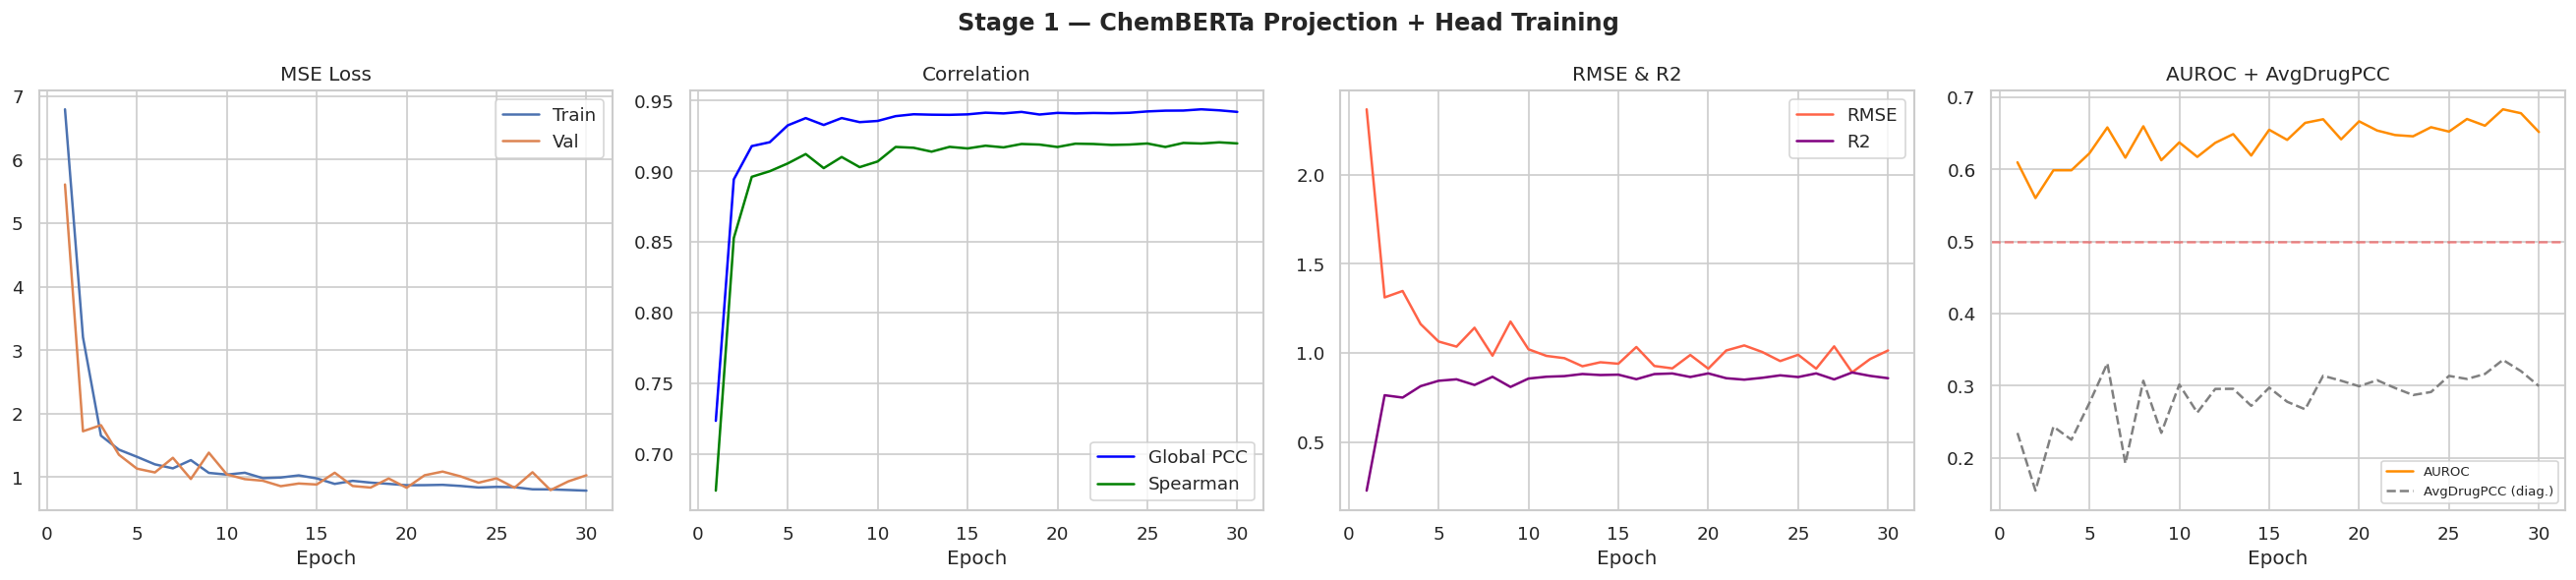

In [8]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 7 — STAGE 1: HEAD + DRUG ENCODER ONLY
# ═══════════════════════════════════════════════════════════════════════
section('7. STAGE 1 TRAINING')

m = get_module()
s1_params = (list(m.drug_encoder.parameters()) +
             list(m.regression_head.parameters()))

opt_s1 = optim.AdamW(s1_params, lr=CONFIG['stage1_lr'],
                      weight_decay=CONFIG['stage1_wd'])

steps = math.ceil(len(train_loader)/CONFIG['grad_accum'])
sched_s1 = optim.lr_scheduler.OneCycleLR(
    opt_s1, max_lr=CONFIG['stage1_lr'],
    total_steps=steps*CONFIG['stage1_epochs'],
    pct_start=CONFIG['warmup_frac'], anneal_strategy='cos',
    div_factor=10.0, final_div_factor=100.0)

# CHANGE 5: torch.amp.GradScaler replaces deprecated torch.cuda.amp.GradScaler
scaler_s1 = torch.amp.GradScaler('cuda', enabled=CONFIG['use_amp'])

best_s1 = -1.0; patience_s1 = 0
hist_s1 = {k:[] for k in ['train_loss','val_loss','val_pearson',
                           'val_spearman','val_rmse','val_r2',
                           'val_auroc','val_drug_pcc']}

n_s1_tr = sum(p.numel() for p in s1_params)
print(f'Training: drug_encoder + regression_head | {n_s1_tr:,} params | {steps} steps/epoch')

for epoch in range(1, CONFIG['stage1_epochs']+1):
    t0 = time.time()
    tr_loss, tr_p, tr_t, tr_d = run_epoch(model, train_loader, opt_s1, scaler_s1,
                                           True, sched_s1, CONFIG['grad_accum'])
    vl_loss, vl_p, vl_t, vl_d = run_epoch(model, val_loader, opt_s1, scaler_s1, False)
    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)

    hist_s1['train_loss'].append(tr_loss)
    hist_s1['val_loss'].append(vl_loss)
    hist_s1['val_pearson'].append(vm['pearson'])
    hist_s1['val_spearman'].append(vm['spearman'])
    hist_s1['val_rmse'].append(vm['rmse'])
    hist_s1['val_r2'].append(vm['r2'])
    hist_s1['val_auroc'].append(vm['avg_drug_auroc'])
    hist_s1['val_drug_pcc'].append(vm['avg_drug_pearson'])

    print(f'[S1 {epoch:02d}/{CONFIG["stage1_epochs"]}]  '
          f'TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  '
          f'PCC={vm["pearson"]:.4f}  SPC={vm["spearman"]:.4f}  '
          f'RMSE={vm["rmse"]:.4f}  R2={vm["r2"]:.4f}  '
          f'AUROC={vm["avg_drug_auroc"]:.4f}  '
          f'AvgDrugPCC={vm["avg_drug_pearson"]:.4f}  '
          f'{time.time()-t0:.0f}s')

    if vm['pearson'] > best_s1:
        best_s1 = vm['pearson']
        patience_s1 = 0
        torch.save(get_module().state_dict(), OUT_DIR + CONFIG['checkpoint_ft'])
        print(f'  Best saved (GlobalPCC={best_s1:.4f})')
    else:
        patience_s1 += 1
        if patience_s1 >= CONFIG['stage1_patience']:
            print(f'  Early stopping @ epoch {epoch}'); break

print(f'\nStage 1 done. Best GlobalPCC={best_s1:.4f}')

fig, ax = plt.subplots(1, 4, figsize=(22,5))
fig.suptitle('Stage 1 — ChemBERTa Projection + Head Training', fontweight='bold')
E = range(1, len(hist_s1['train_loss'])+1)
ax[0].plot(E, hist_s1['train_loss'], label='Train'); ax[0].plot(E, hist_s1['val_loss'], label='Val')
ax[0].set_title('MSE Loss'); ax[0].legend()
ax[1].plot(E, hist_s1['val_pearson'], color='blue', label='Global PCC')
ax[1].plot(E, hist_s1['val_spearman'], color='green', label='Spearman')
ax[1].set_title('Correlation'); ax[1].legend()
ax[2].plot(E, hist_s1['val_rmse'], color='tomato', label='RMSE')
ax[2].plot(E, hist_s1['val_r2'], color='purple', label='R2')
ax[2].set_title('RMSE & R2'); ax[2].legend()
ax[3].plot(E, hist_s1['val_auroc'], color='darkorange', label='AUROC')
ax[3].plot(E, hist_s1['val_drug_pcc'], color='gray', ls='--', label='AvgDrugPCC (diag.)')
ax[3].axhline(0.5, color='red', ls='--', alpha=0.4)
ax[3].set_title('AUROC + AvgDrugPCC'); ax[3].legend(fontsize=8)
for a in ax: a.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(OUT_DIR+'v4_stage1_curves.png', dpi=150); plt.show()


══════════════════════════════════════════════════════════════════════
  8. STAGE 2 TRAINING
══════════════════════════════════════════════════════════════════════
Unfreezing LAST 2/4 cross-layers + fusion:
  base_model.mrna_enc               FROZEN                0
  base_model.cnv_enc                FROZEN                0
  base_model.mut_enc                FROZEN                0
  base_model.meth_enc               FROZEN                0
  base_model.cross_layers           TRAINABLE    14,195,712
  base_model.fusion                 TRAINABLE         6,148
  base_model.classifier             FROZEN                0
  drug_encoder + head           TRAINABLE   1,580,673
Total trainable S2: 15,782,533  (v3 was ~30.8M — this is 15.8M)
[S2 01/40]  TrLoss=0.7849  VlLoss=0.9845  PCC=0.9434  SPC=0.9210  RMSE=0.9922  R2=0.8643  AUROC=0.6662  AvgDrugPCC=0.3210  58s
  Best saved (GlobalPCC=0.9434)
[S2 02/40]  TrLoss=0.8190  VlLoss=0.9865  PCC=0.9437  SPC=0.9211  RMSE=0.9932  R2=0.8640  AUROC

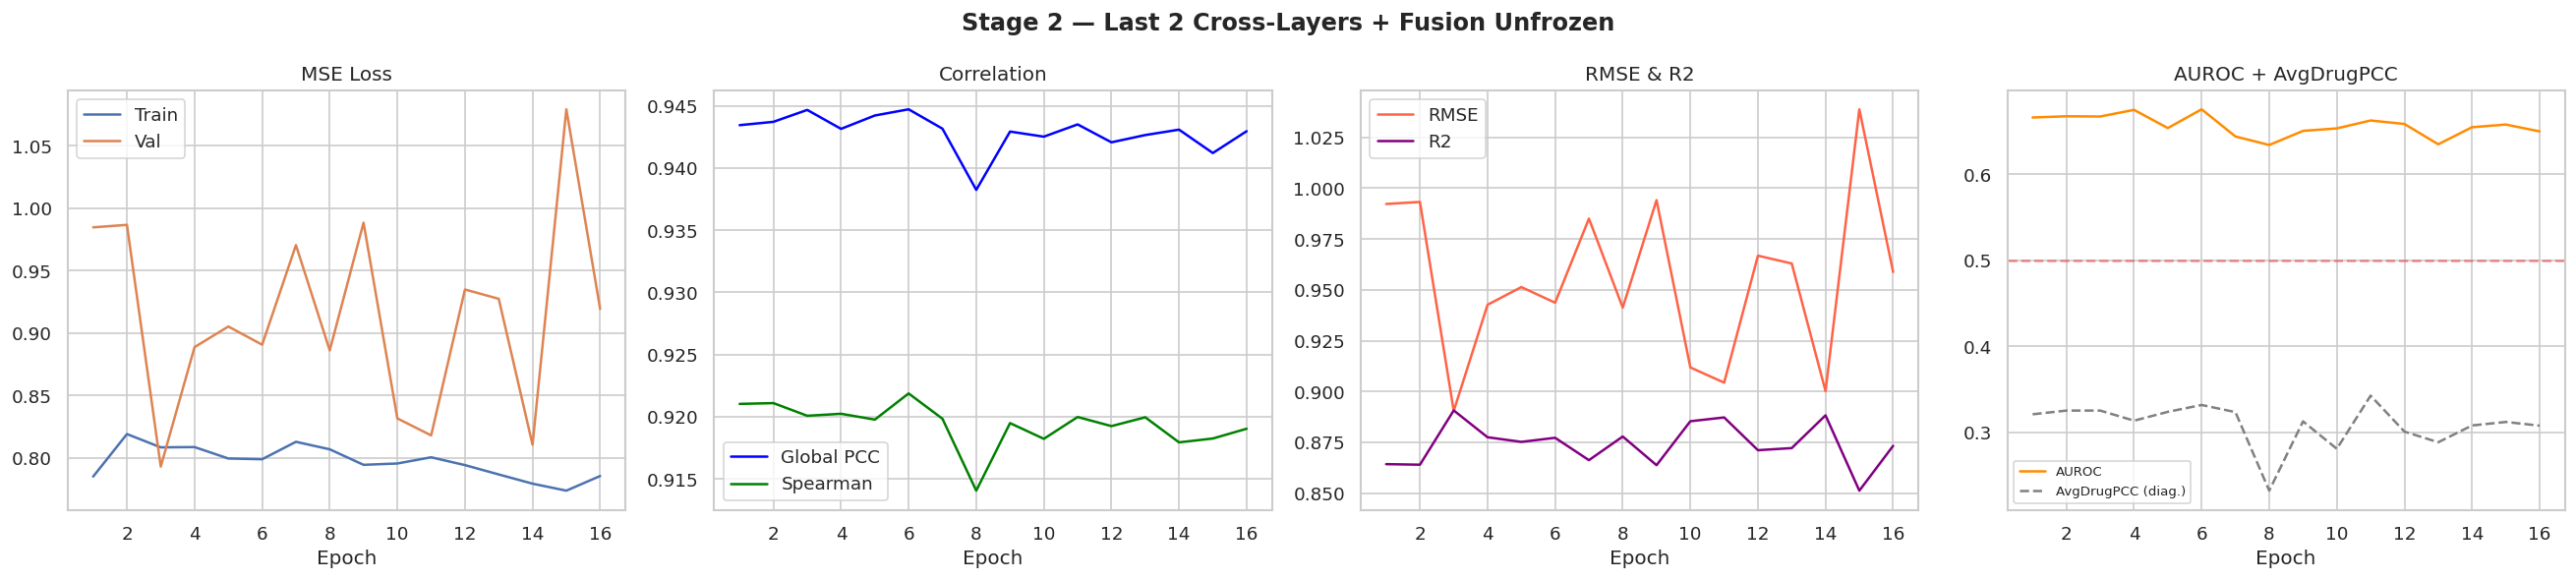

In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 8 — STAGE 2: UNFREEZE LAST N CROSS-LAYERS + FUSION
#  CHANGE 3: Unfreeze only last 2 cross-layers (v3 unfroze ALL 4)
# ═══════════════════════════════════════════════════════════════════════
section('8. STAGE 2 TRAINING')

get_module().load_state_dict(
    torch.load(OUT_DIR+CONFIG['checkpoint_ft'], map_location=DEVICE))
m = get_module()

n_cross  = CONFIG['stage2_unfreeze_n_cross']
n_total  = CONFIG['num_cross_layers']
for i, layer in enumerate(m.base_model.cross_layers):
    if i >= (n_total - n_cross):
        for p in layer.parameters(): p.requires_grad = True
for p in m.base_model.fusion.parameters(): p.requires_grad = True

print(f'Unfreezing LAST {n_cross}/{n_total} cross-layers + fusion:')
for name, child in m.base_model.named_children():
    n_tr = sum(p.numel() for p in child.parameters() if p.requires_grad)
    print(f'  base_model.{name:<22} {"TRAINABLE" if n_tr else "FROZEN":<12} {n_tr:>10,}')
head_p = sum(p.numel() for p in list(m.drug_encoder.parameters()) +
                                  list(m.regression_head.parameters()))
print(f'  drug_encoder + head           TRAINABLE  {head_p:>10,}')
total_s2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable S2: {total_s2:,}  (v3 was ~30.8M — this is {total_s2/1e6:.1f}M)')

cross_params = [p for i, layer in enumerate(m.base_model.cross_layers)
                for p in layer.parameters()
                if i >= (n_total - n_cross)]

opt_s2 = optim.AdamW([
    {'params': m.regression_head.parameters(),  'lr': CONFIG['stage2_lr_head']},
    {'params': m.drug_encoder.parameters(),     'lr': CONFIG['stage2_lr_head']},
    {'params': cross_params,                    'lr': CONFIG['stage2_lr_cross']},
    {'params': m.base_model.fusion.parameters(),'lr': CONFIG['stage2_lr_cross']},
], weight_decay=CONFIG['stage2_wd'])

steps2   = math.ceil(len(train_loader)/CONFIG['grad_accum'])
sched_s2 = optim.lr_scheduler.OneCycleLR(
    opt_s2,
    max_lr=[CONFIG['stage2_lr_head'], CONFIG['stage2_lr_head'],
            CONFIG['stage2_lr_cross'], CONFIG['stage2_lr_cross']],
    total_steps=steps2*CONFIG['stage2_epochs'],
    pct_start=CONFIG['warmup_frac'], anneal_strategy='cos',
    div_factor=10.0, final_div_factor=100.0)

scaler_s2 = torch.amp.GradScaler('cuda', enabled=CONFIG['use_amp'])

best_s2 = -1.0; patience_s2 = 0
hist_s2 = {k:[] for k in ['train_loss','val_loss','val_pearson',
                           'val_spearman','val_rmse','val_r2',
                           'val_auroc','val_drug_pcc']}

for epoch in range(1, CONFIG['stage2_epochs']+1):
    t0 = time.time()
    tr_loss, tr_p, tr_t, tr_d = run_epoch(model, train_loader, opt_s2, scaler_s2,
                                           True, sched_s2, CONFIG['grad_accum'])
    vl_loss, vl_p, vl_t, vl_d = run_epoch(model, val_loader, opt_s2, scaler_s2, False)
    vm = compute_metrics(vl_p, vl_t, vl_d, id_to_drug)

    hist_s2['train_loss'].append(tr_loss)
    hist_s2['val_loss'].append(vl_loss)
    hist_s2['val_pearson'].append(vm['pearson'])
    hist_s2['val_spearman'].append(vm['spearman'])
    hist_s2['val_rmse'].append(vm['rmse'])
    hist_s2['val_r2'].append(vm['r2'])
    hist_s2['val_auroc'].append(vm['avg_drug_auroc'])
    hist_s2['val_drug_pcc'].append(vm['avg_drug_pearson'])

    print(f'[S2 {epoch:02d}/{CONFIG["stage2_epochs"]}]  '
          f'TrLoss={tr_loss:.4f}  VlLoss={vl_loss:.4f}  '
          f'PCC={vm["pearson"]:.4f}  SPC={vm["spearman"]:.4f}  '
          f'RMSE={vm["rmse"]:.4f}  R2={vm["r2"]:.4f}  '
          f'AUROC={vm["avg_drug_auroc"]:.4f}  '
          f'AvgDrugPCC={vm["avg_drug_pearson"]:.4f}  '
          f'{time.time()-t0:.0f}s')

    if vm['pearson'] > best_s2:
        best_s2 = vm['pearson']
        patience_s2 = 0
        torch.save(get_module().state_dict(), OUT_DIR+CONFIG['checkpoint_ft'])
        print(f'  Best saved (GlobalPCC={best_s2:.4f})')
    else:
        patience_s2 += 1
        if patience_s2 >= CONFIG['stage2_patience']:
            print(f'  Early stopping @ epoch {epoch}'); break

print(f'\nStage 2 done. Best GlobalPCC={best_s2:.4f}')

fig, ax = plt.subplots(1, 4, figsize=(22,5))
fig.suptitle(f'Stage 2 — Last {n_cross} Cross-Layers + Fusion Unfrozen', fontweight='bold')
E = range(1, len(hist_s2['train_loss'])+1)
ax[0].plot(E, hist_s2['train_loss'], label='Train'); ax[0].plot(E, hist_s2['val_loss'], label='Val')
ax[0].set_title('MSE Loss'); ax[0].legend()
ax[1].plot(E, hist_s2['val_pearson'], color='blue', label='Global PCC')
ax[1].plot(E, hist_s2['val_spearman'], color='green', label='Spearman')
ax[1].set_title('Correlation'); ax[1].legend()
ax[2].plot(E, hist_s2['val_rmse'], color='tomato', label='RMSE')
ax[2].plot(E, hist_s2['val_r2'], color='purple', label='R2')
ax[2].set_title('RMSE & R2'); ax[2].legend()
ax[3].plot(E, hist_s2['val_auroc'], color='darkorange', label='AUROC')
ax[3].plot(E, hist_s2['val_drug_pcc'], color='gray', ls='--', label='AvgDrugPCC (diag.)')
ax[3].axhline(0.5, color='red', ls='--', alpha=0.4)
ax[3].set_title('AUROC + AvgDrugPCC'); ax[3].legend(fontsize=8)
for a in ax: a.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(OUT_DIR+'v4_stage2_curves.png', dpi=150); plt.show()


══════════════════════════════════════════════════════════════════════
  9. TEST EVALUATION
══════════════════════════════════════════════════════════════════════

  FINAL TEST RESULTS — OncoBridge v4 Drug Response
  Global Pearson (PCC):     0.9400
  Global Spearman (SPC):    0.9189
  Global R2:                0.8658
  RMSE (ln-IC50):           1.0020
  Avg Drug AUROC:           0.6081
  Avg Drug Pearson (diag):  0.2457

Top 15 drugs by per-drug Pearson:
              Pearson   AUROC  N_Samples
EPIRUBICIN     0.6239  0.7196       55.0
WZ4003         0.6025  0.6667       13.0
MITOXANTRONE   0.5808  0.7539       32.0
VORINOSTAT     0.5784  0.8176       54.0
CISPLATIN      0.4862  0.7143       14.0
TENIPOSIDE     0.4855  0.6759       38.0
PEVONEDISTAT   0.4822  0.7095       41.0
AZD6738        0.4731  0.7238       29.0
MK-1775        0.4719  0.7265       53.0
TALAZOPARIB    0.4597  0.9722       12.0
DINACICLIB     0.4476  0.6806       48.0
AZD7762        0.4197  0.6593       63.0
DOCETA

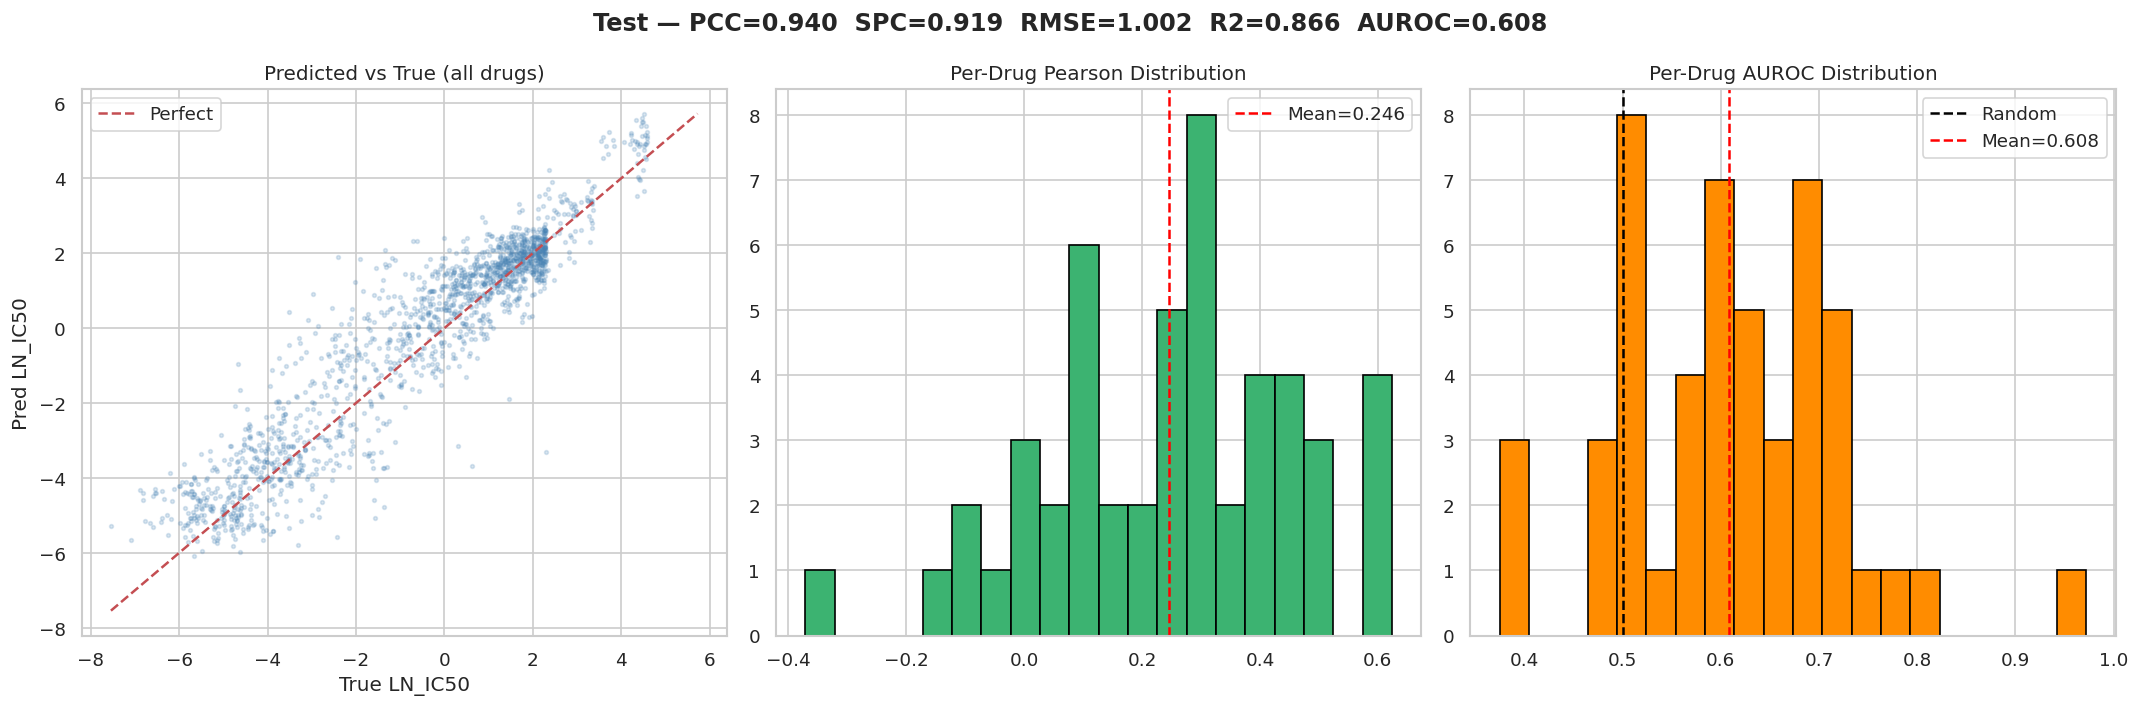

In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 9 — TEST SET EVALUATION
# ═══════════════════════════════════════════════════════════════════════
section('9. TEST EVALUATION')

get_module().load_state_dict(
    torch.load(OUT_DIR+CONFIG['checkpoint_ft'], map_location=DEVICE))
model.eval()

te_loss, te_p, te_t, te_d = run_epoch(model, test_loader, None, None, False)
te_m = compute_metrics(te_p, te_t, te_d, id_to_drug)

print('\n' + '='*70)
print('  FINAL TEST RESULTS — OncoBridge v4 Drug Response')
print('='*70)
print(f'  Global Pearson (PCC):     {te_m["pearson"]:.4f}')
print(f'  Global Spearman (SPC):    {te_m["spearman"]:.4f}')
print(f'  Global R2:                {te_m["r2"]:.4f}')
print(f'  RMSE (ln-IC50):           {te_m["rmse"]:.4f}')
print(f'  Avg Drug AUROC:           {te_m["avg_drug_auroc"]:.4f}')
print(f'  Avg Drug Pearson (diag):  {te_m["avg_drug_pearson"]:.4f}')
print('='*70)

drug_df = pd.DataFrame(te_m['per_drug']).T.sort_values('pearson', ascending=False)
drug_df.columns = ['Pearson','AUROC','N_Samples']
print(f'\nTop 15 drugs by per-drug Pearson:')
print(drug_df.head(15).round(4).to_string())
print(f'\nBottom 5 drugs (hardest to predict):')
print(drug_df.tail(5).round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Test — PCC={te_m["pearson"]:.3f}  SPC={te_m["spearman"]:.3f}  '
             f'RMSE={te_m["rmse"]:.3f}  R2={te_m["r2"]:.3f}  AUROC={te_m["avg_drug_auroc"]:.3f}',
             fontweight='bold')
axes[0].scatter(te_t, te_p, alpha=0.2, s=5, c='steelblue')
mn,mx = min(te_t.min(),te_p.min()), max(te_t.max(),te_p.max())
axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Perfect')
axes[0].set_xlabel('True LN_IC50'); axes[0].set_ylabel('Pred LN_IC50')
axes[0].set_title('Predicted vs True (all drugs)'); axes[0].legend()
axes[1].hist(drug_df['Pearson'], bins=20, color='mediumseagreen', edgecolor='black')
axes[1].axvline(drug_df['Pearson'].mean(), color='red', ls='--',
                label=f'Mean={drug_df["Pearson"].mean():.3f}')
axes[1].set_title('Per-Drug Pearson Distribution'); axes[1].legend()
axes[2].hist(drug_df['AUROC'], bins=20, color='darkorange', edgecolor='black')
axes[2].axvline(0.5, color='black', ls='--', label='Random')
axes[2].axvline(drug_df['AUROC'].mean(), color='red', ls='--',
                label=f'Mean={drug_df["AUROC"].mean():.3f}')
axes[2].set_title('Per-Drug AUROC Distribution'); axes[2].legend()
plt.tight_layout(); plt.savefig(OUT_DIR+'v4_test_evaluation.png', dpi=150); plt.show()

In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 10 — DRUG COLD-START EVALUATION
# ═══════════════════════════════════════════════════════════════════════
section('10. DRUG COLD-START EVALUATION')

if len(cold_ds) > 0:
    cs_loss, cs_p, cs_t, cs_d = run_epoch(model, cold_loader, None, None, False)
    cs_m = compute_metrics(cs_p, cs_t, cs_d, id_to_drug)

    print('\n' + '='*70)
    print('  DRUG COLD-START RESULTS')
    print('  (Drugs never seen during training)')
    print('='*70)
    print(f'  Global Pearson:      {cs_m["pearson"]:.4f}')
    print(f'  Global Spearman:     {cs_m["spearman"]:.4f}')
    print(f'  Global R2:           {cs_m["r2"]:.4f}')
    print(f'  RMSE:                {cs_m["rmse"]:.4f}')
    print(f'  Avg Drug AUROC:      {cs_m["avg_drug_auroc"]:.4f}')
    print(f'  Avg Drug Pearson:    {cs_m["avg_drug_pearson"]:.4f}  (diagnostic)')
    print('='*70)
    print(f'\n  DTLCDR (2025) cold-start GlobalPCC: 0.6210 (SOTA)')
    print(f'  OncoBridge v4 cold-start GlobalPCC: {cs_m["pearson"]:.4f}')

    cs_drug_df = pd.DataFrame(cs_m['per_drug']).T.sort_values('pearson', ascending=False)
    cs_drug_df.columns = ['Pearson','AUROC','N_Samples']
    print(f'\nCold-start per-drug results ({len(cs_drug_df)} drugs):')
    print(cs_drug_df.round(4).to_string())
else:
    print('No cold-start data available.')
    cs_m = {'pearson': None, 'spearman': None, 'r2': None,
            'rmse': None, 'avg_drug_pearson': None, 'avg_drug_auroc': None}


══════════════════════════════════════════════════════════════════════
  10. DRUG COLD-START EVALUATION
══════════════════════════════════════════════════════════════════════

  DRUG COLD-START RESULTS
  (Drugs never seen during training)
  Global Pearson:      0.6570
  Global Spearman:     0.3317
  Global R2:           0.0681
  RMSE:                2.0511
  Avg Drug AUROC:      0.6457
  Avg Drug Pearson:    0.3122  (diagnostic)

  DTLCDR (2025) cold-start GlobalPCC: 0.6210 (SOTA)
  OncoBridge v4 cold-start GlobalPCC: 0.6570

Cold-start per-drug results (8 drugs):
             Pearson   AUROC  N_Samples
ABT-737       0.5172  0.7702      139.0
NAVITOCLAX    0.4555  0.6961      204.0
AZ960         0.3918  0.6943      107.0
FORETINIB     0.3691  0.6616      330.0
SORAFENIB     0.3580  0.6395      196.0
VINORELBINE   0.2936  0.6553      151.0
OBATOCLAX     0.2210  0.5789      236.0
BVD-523      -0.1085  0.4701       78.0



══════════════════════════════════════════════════════════════════════
  11. ABLATION STUDY
══════════════════════════════════════════════════════════════════════
Running ablation — zeroing one modality at a time...

  All 4 modalities (full model)        AvgDrugPCC=0.2457  GlobalPCC=0.9400  RMSE=1.0020
  No mRNA                              AvgDrugPCC=-0.0749  GlobalPCC=0.9328  RMSE=1.1354
  No CNV                               AvgDrugPCC=0.2358  GlobalPCC=0.9386  RMSE=1.0656
  No Mutation                          AvgDrugPCC=0.2653  GlobalPCC=0.9409  RMSE=1.0216
  No Methylation                       AvgDrugPCC=0.1720  GlobalPCC=0.9339  RMSE=1.0248
  mRNA only                            AvgDrugPCC=0.2194  GlobalPCC=0.9366  RMSE=0.9714
  mRNA + CNV only                      AvgDrugPCC=0.2287  GlobalPCC=0.9363  RMSE=1.0148
  mRNA + Mut only                      AvgDrugPCC=0.1389  GlobalPCC=0.9345  RMSE=0.9791

                      Setting  AvgDrugPCC  GlobalPCC   RMSE  AUROC
All 4 mod

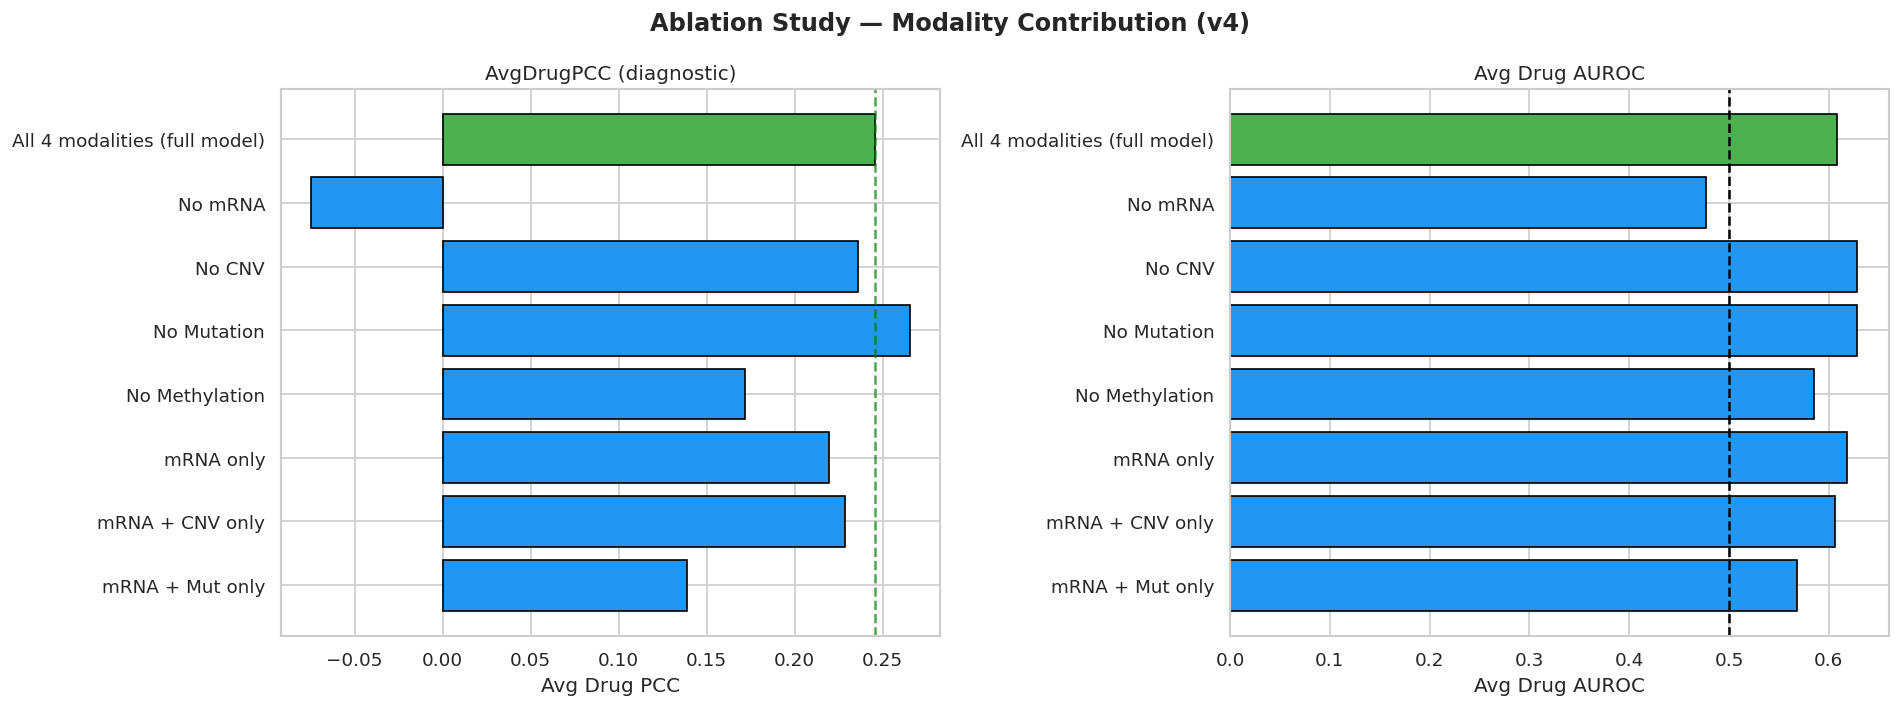

In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 11 — ABLATION STUDY
#  Key question: did Modality Dropout fix the mutation collapse?
#  In v3: removing mutation dropped AvgDrugPCC by only 0.0006.
#  In v4: this gap should be larger if dropout worked.
# ═══════════════════════════════════════════════════════════════════════
section('11. ABLATION STUDY')

def ablation_run_epoch(ablation_model, loader, zero_mods=None):
    ablation_model.eval()
    all_p, all_t, all_d = [], [], []
    with torch.no_grad():
        for batch in loader:
            mrna, cnv, mut, meth, drug_emb, ic50, did = batch
            mrna     = mrna.to(DEVICE);     cnv  = cnv.to(DEVICE)
            mut      = mut.to(DEVICE);      meth = meth.to(DEVICE)
            drug_emb = drug_emb.to(DEVICE); ic50 = ic50.to(DEVICE)
            if zero_mods:
                if 'mrna' in zero_mods: mrna = torch.zeros_like(mrna)
                if 'cnv'  in zero_mods: cnv  = torch.zeros_like(cnv)
                if 'mut'  in zero_mods: mut  = torch.zeros_like(mut)
                if 'meth' in zero_mods: meth = torch.zeros_like(meth)
            pred = ablation_model(mrna, cnv, mut, meth, drug_emb).squeeze(1)
            all_p.append(pred.cpu().numpy())
            all_t.append(ic50.cpu().numpy())
            all_d.append(did.numpy())
    p = np.concatenate(all_p); t = np.concatenate(all_t); d = np.concatenate(all_d)
    m = compute_metrics(p, t, d, id_to_drug)
    return m['avg_drug_pearson'], m['pearson'], m['rmse'], m['avg_drug_auroc']

print('Running ablation — zeroing one modality at a time...\n')

ablation_results = []
ablation_configs = [
    ('All 4 modalities (full model)',  []),
    ('No mRNA',                        ['mrna']),
    ('No CNV',                         ['cnv']),
    ('No Mutation',                    ['mut']),
    ('No Methylation',                 ['meth']),
    ('mRNA only',                      ['cnv','mut','meth']),
    ('mRNA + CNV only',                ['mut','meth']),
    ('mRNA + Mut only',                ['cnv','meth']),
]

for name, zero_mods in ablation_configs:
    dp, gp, rmse, auroc = ablation_run_epoch(model, test_loader, zero_mods)
    ablation_results.append({'Setting': name, 'AvgDrugPCC': round(dp,4),
                              'GlobalPCC': round(gp,4), 'RMSE': round(rmse,4),
                              'AUROC': round(auroc,4)})
    print(f'  {name:<35}  AvgDrugPCC={dp:.4f}  GlobalPCC={gp:.4f}  RMSE={rmse:.4f}')

abl_df = pd.DataFrame(ablation_results)
print('\n' + abl_df.to_string(index=False))

print('\nKey check: In v3, No-Mutation dropped AvgDrugPCC by only 0.0006.')
full_pcc = abl_df.loc[abl_df['Setting']=='All 4 modalities (full model)','AvgDrugPCC'].values[0]
no_mut   = abl_df.loc[abl_df['Setting']=='No Mutation','AvgDrugPCC'].values[0]
print(f'v4 Full: {full_pcc:.4f}  ->  No Mutation: {no_mut:.4f}  (delta={full_pcc-no_mut:+.4f})')
if full_pcc - no_mut > 0.01:
    print('Modality Dropout worked — mutation now contributes meaningfully.')
else:
    print('Mutation still contributes little. Consider increasing dropout_p.')

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ablation Study — Modality Contribution (v4)', fontweight='bold')
colors = ['#4CAF50' if i==0 else '#2196F3' for i in range(len(abl_df))]
ax[0].barh(abl_df['Setting'], abl_df['AvgDrugPCC'], color=colors, edgecolor='black')
ax[0].set_xlabel('Avg Drug PCC'); ax[0].invert_yaxis()
ax[0].axvline(abl_df.loc[0,'AvgDrugPCC'], color='green', ls='--', alpha=0.7)
ax[0].set_title('AvgDrugPCC (diagnostic)')
ax[1].barh(abl_df['Setting'], abl_df['AUROC'], color=colors, edgecolor='black')
ax[1].set_xlabel('Avg Drug AUROC'); ax[1].invert_yaxis()
ax[1].axvline(0.5, color='black', ls='--', label='Random')
ax[1].set_title('Avg Drug AUROC')
plt.tight_layout()
plt.savefig(OUT_DIR+'v4_ablation_study.png', dpi=150); plt.show()
abl_df.to_csv(OUT_DIR+'v4_ablation_results.csv', index=False)


══════════════════════════════════════════════════════════════════════
  12. BENCHMARK COMPARISON
══════════════════════════════════════════════════════════════════════
           Model Dataset  Setting  GlobalPCC     RMSE    AUROC                                       Notes
Ridge Regression    GDSC     Warm   0.780000 2.368000      NaN                                    Baseline
  DeepCDR (2020)    GDSC     Warm   0.923000 1.058000 0.841000                           UGCN drug encoder
  DRN-CDR (2024)   GDSC2     Warm   0.794000 0.924000 0.762000                   ResNet, cancer genes only
 GraphDRP (2022)   GDSC2     Warm   0.939000      NaN      NaN                                    GNN drug
  DeepTTA (2022)   GDSC2     Warm   0.937000      NaN      NaN                            Transformer drug
    TGDRP (2022)   GDSC2     Warm   0.890000      NaN      NaN                                    Twin GNN
   DTLCDR (2025)   GDSC2     Warm   0.949000      NaN      NaN                   

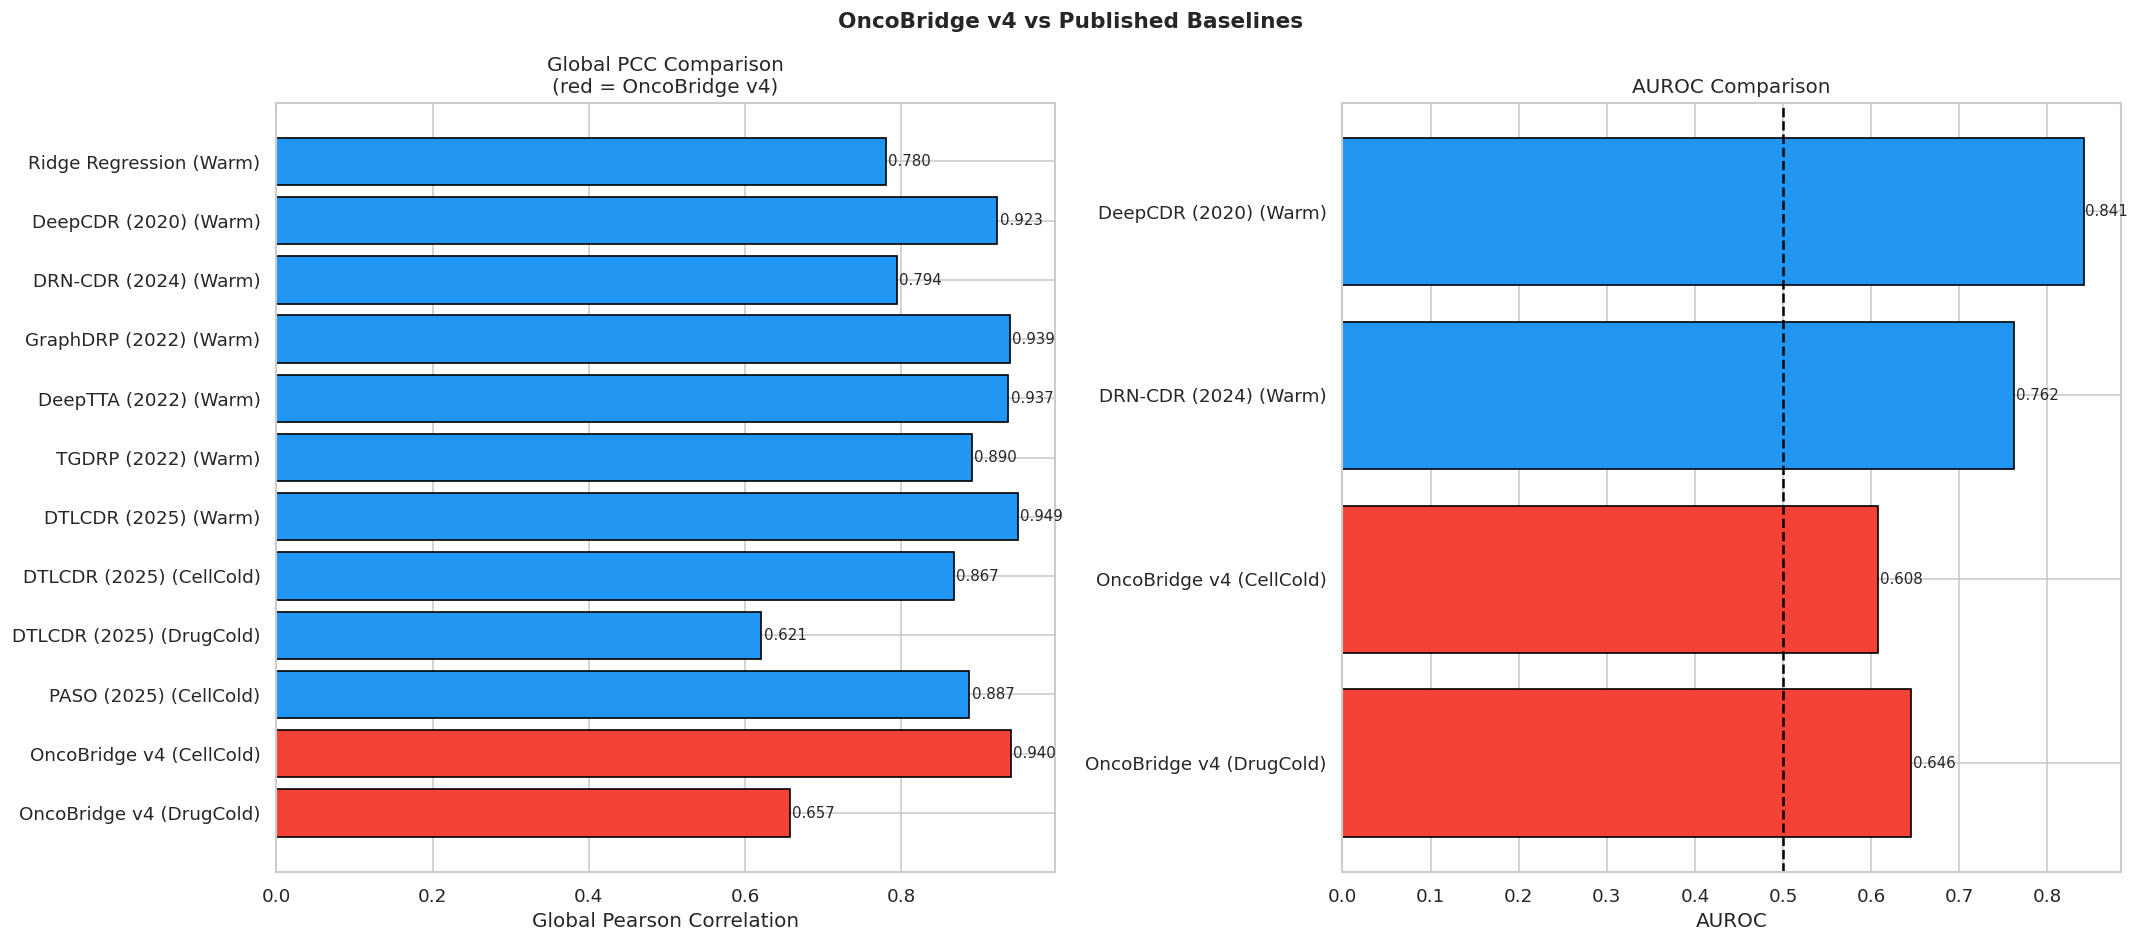


DATASET NOTE:
  OncoBridge uses GDSC1+2 combined — more training data than GDSC2-only baselines.
  Global PCC comparison is NOT apple-to-apple. Drug cold-start PCC is fairer.


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 12 — BENCHMARK COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════════════
section('12. BENCHMARK COMPARISON')

benchmarks = [
    ('Ridge Regression',  'GDSC',   'Warm',      0.780,  2.368, None,  'Baseline'),
    ('DeepCDR (2020)',    'GDSC',   'Warm',      0.923,  1.058, 0.841, 'UGCN drug encoder'),
    ('DRN-CDR (2024)',    'GDSC2',  'Warm',      0.794,  0.924, 0.762, 'ResNet, cancer genes only'),
    ('GraphDRP (2022)',   'GDSC2',  'Warm',      0.939,  None,  None,  'GNN drug'),
    ('DeepTTA (2022)',    'GDSC2',  'Warm',      0.937,  None,  None,  'Transformer drug'),
    ('TGDRP (2022)',      'GDSC2',  'Warm',      0.890,  None,  None,  'Twin GNN'),
    ('DTLCDR (2025)',     'GDSC2',  'Warm',      0.949,  None,  None,  'Target profiles+scBERT'),
    ('DTLCDR (2025)',     'GDSC2',  'CellCold',  0.867,  None,  None,  'Unseen cell lines'),
    ('DTLCDR (2025)',     'GDSC2',  'DrugCold',  0.621,  None,  None,  'Unseen drugs <- KEY'),
    ('PASO (2025)',       'GDSC2',  'CellCold',  0.887,  None,  None,  'Pathway features'),
    ('OncoBridge v4',    'GDSC1+2','CellCold',
     te_m['pearson'], te_m['rmse'], te_m['avg_drug_auroc'],
     'TCGA transfer | ChemBERTa drug | ModDropout'),
]
if cs_m['pearson'] is not None:
    benchmarks.append((
        'OncoBridge v4', 'GDSC1+2', 'DrugCold',
        cs_m['pearson'], cs_m['rmse'], cs_m['avg_drug_auroc'],
        'TCGA transfer | ChemBERTa drug | ModDropout'))

bm_df = pd.DataFrame(benchmarks,
    columns=['Model','Dataset','Setting','GlobalPCC','RMSE','AUROC','Notes'])
print(bm_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('OncoBridge v4 vs Published Baselines', fontweight='bold', fontsize=13)

pcc_df = bm_df[bm_df['GlobalPCC'].notna()].copy()
colors = ['#F44336' if 'v4' in m else '#2196F3' for m in pcc_df['Model']]
bars = axes[0].barh(
    pcc_df['Model'] + ' (' + pcc_df['Setting'] + ')',
    pcc_df['GlobalPCC'], color=colors, edgecolor='black')
axes[0].set_xlabel('Global Pearson Correlation')
axes[0].invert_yaxis()
axes[0].set_title('Global PCC Comparison\n(red = OncoBridge v4)')
for bar, v in zip(bars, pcc_df['GlobalPCC']):
    axes[0].text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=9)

auc_df = bm_df[bm_df['AUROC'].notna()].copy()
colors2 = ['#F44336' if 'v4' in m else '#2196F3' for m in auc_df['Model']]
bars2 = axes[1].barh(
    auc_df['Model'] + ' (' + auc_df['Setting'] + ')',
    auc_df['AUROC'], color=colors2, edgecolor='black')
axes[1].set_xlabel('AUROC')
axes[1].invert_yaxis()
axes[1].axvline(0.5, color='black', ls='--', label='Random')
axes[1].set_title('AUROC Comparison')
for bar, v in zip(bars2, auc_df['AUROC']):
    axes[1].text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout(); plt.savefig(OUT_DIR+'v4_benchmark_comparison.png', dpi=150); plt.show()

print('\nDATASET NOTE:')
print('  OncoBridge uses GDSC1+2 combined — more training data than GDSC2-only baselines.')
print('  Global PCC comparison is NOT apple-to-apple. Drug cold-start PCC is fairer.')
bm_df.to_csv(OUT_DIR+'v4_benchmark_comparison.csv', index=False)


══════════════════════════════════════════════════════════════════════
  13. DRUG RANKINGS & DELTA-IC50 HEATMAP
══════════════════════════════════════════════════════════════════════


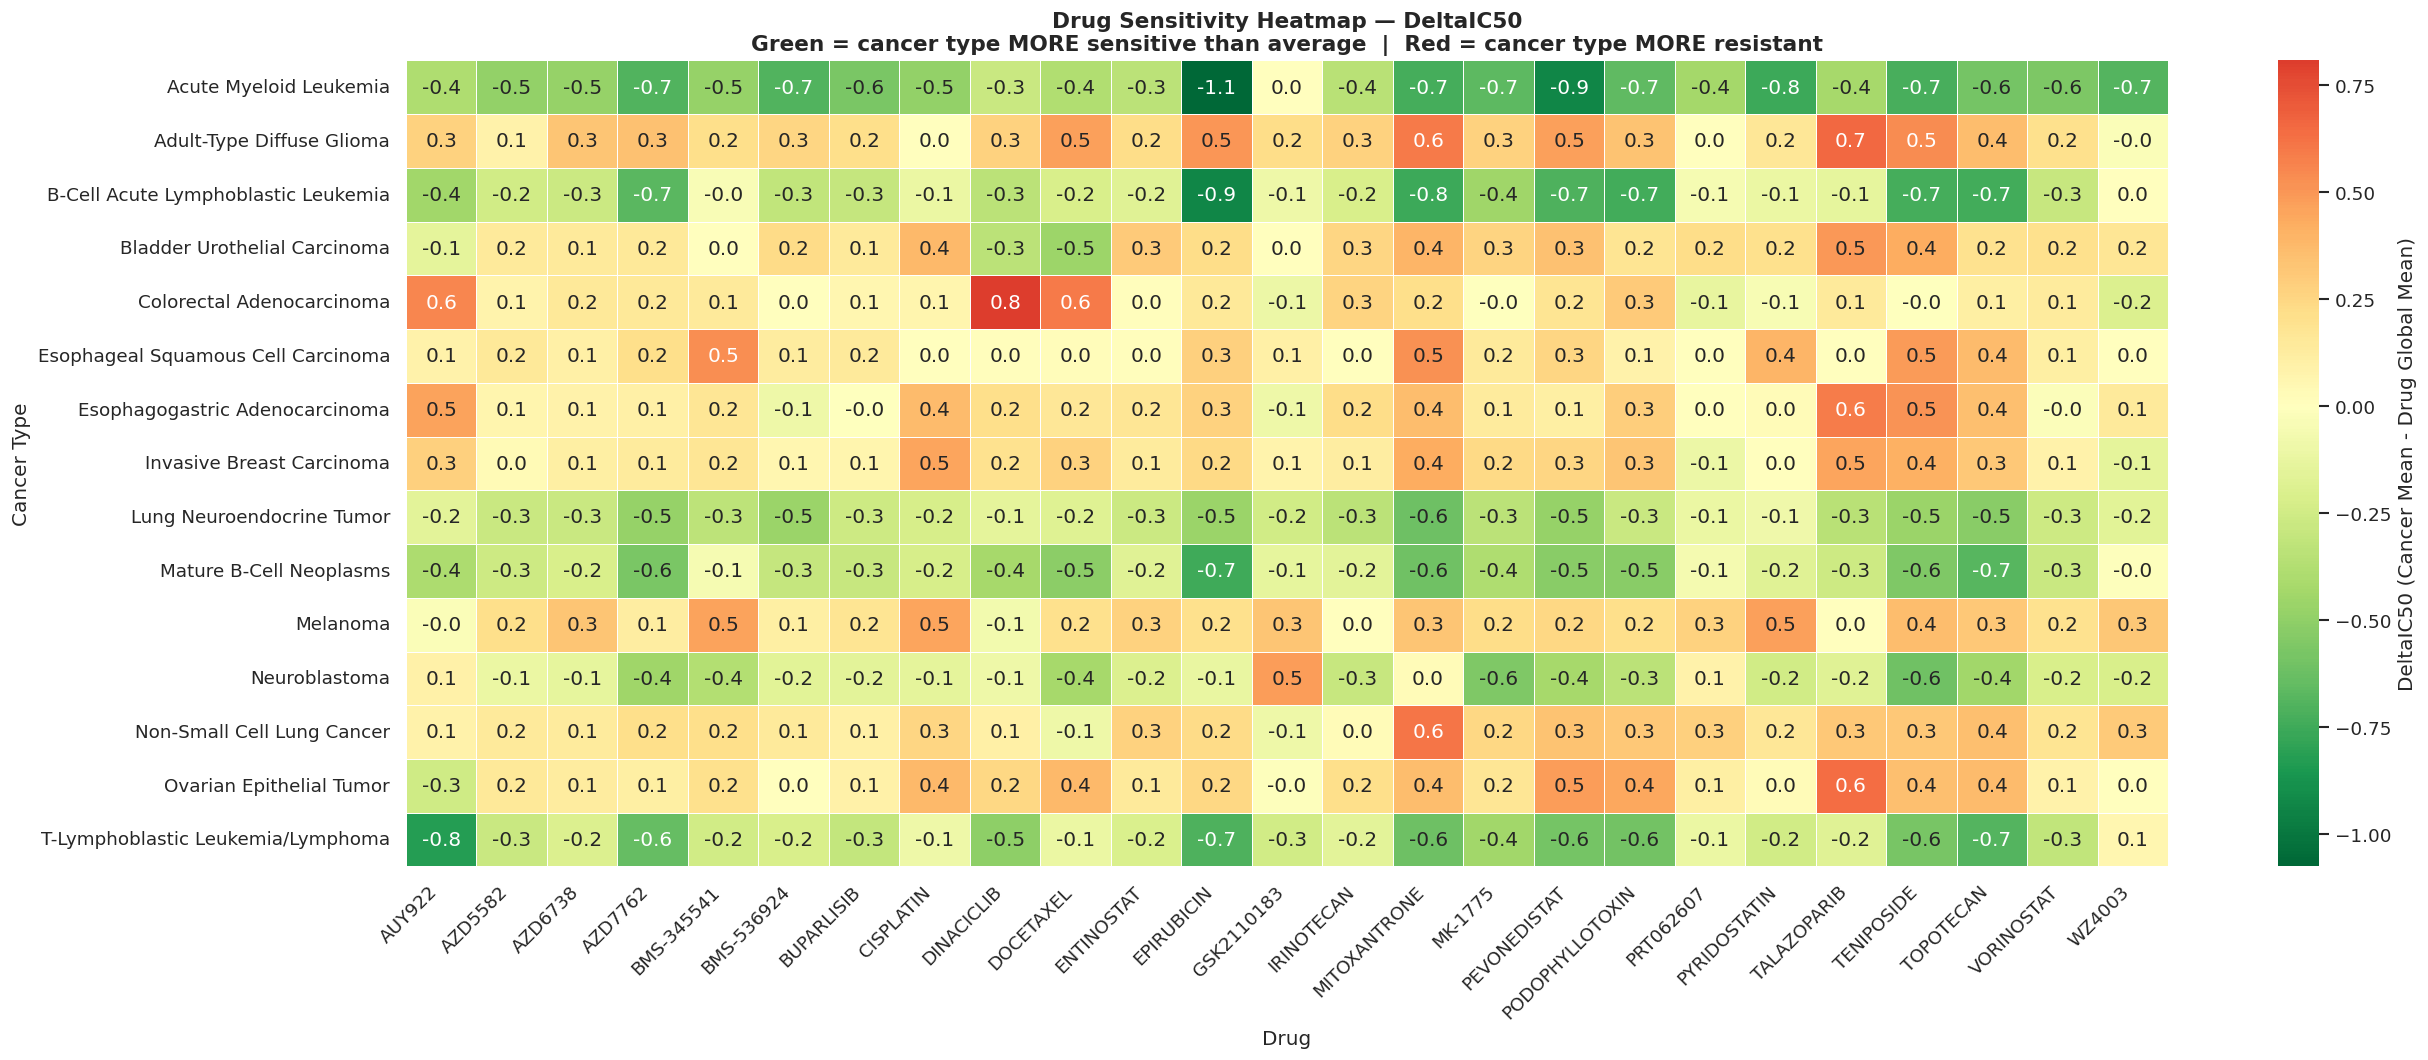


Top 5 predicted sensitive drugs per cancer type (lowest predicted IC50):
                                                                             OncotreePrimaryDisease    DRUG_NAME  mean_pred_ic50  mean_true_ic50  n_cell_lines
                                                                             Acute Myeloid Leukemia   BORTEZOMIB       -5.660004       -5.034787             9
                                                                             Acute Myeloid Leukemia DACTINOMYCIN       -5.317374       -4.878555             7
                                                                             Acute Myeloid Leukemia  VINBLASTINE       -5.207723       -5.793852             9
                                                                             Acute Myeloid Leukemia   PACLITAXEL       -5.151540       -4.980347             8
                                                                             Acute Myeloid Leukemia    DOCETAXEL       -4.910929   

In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 13 — DRUG RANKINGS + DELTA-IC50 SENSITIVITY HEATMAP
#  CHANGE 4 (bug fix): mean_true_ic50 now correctly uses 'ic50_value'
# ═══════════════════════════════════════════════════════════════════════
section('13. DRUG RANKINGS & DELTA-IC50 HEATMAP')

all_ds = DrugResponseDataset(
    pd.concat([ic50_warm, ic50_cold]).drop_duplicates(['ModelID','DRUG_NAME']),
    all_cell_lines, mrna_arr, cnv_arr, mut_arr, meth_arr, DRUG_EMB_MATRIX)
all_loader2 = DataLoader(all_ds, batch_size=CONFIG['batch_size']*2,
                         shuffle=False, num_workers=nw, pin_memory=True)
_, all_p, all_t, all_d = run_epoch(model, all_loader2, None, None, False)

all_recs = pd.concat([ic50_warm, ic50_cold]).drop_duplicates(
    ['ModelID','DRUG_NAME']).reset_index(drop=True)
assert len(all_recs) == len(all_p), f'Mismatch {len(all_recs)} vs {len(all_p)}'
all_recs['PRED_IC50'] = all_p

drug_global_mean = all_recs.groupby('DRUG_NAME')['PRED_IC50'].mean()
all_recs['delta_ic50'] = all_recs.apply(
    lambda r: r['PRED_IC50'] - drug_global_mean[r['DRUG_NAME']], axis=1)

top_cancers    = all_recs['OncotreePrimaryDisease'].value_counts().head(15).index
top_drugs_warm = (pd.DataFrame(te_m['per_drug']).T
                  .sort_values('pearson', ascending=False).head(25).index.tolist())

pivot = (all_recs[all_recs['OncotreePrimaryDisease'].isin(top_cancers) &
                  all_recs['DRUG_NAME'].isin(top_drugs_warm)]
         .groupby(['OncotreePrimaryDisease','DRUG_NAME'])['delta_ic50'].mean()
         .unstack(fill_value=0))

plt.figure(figsize=(22, 9))
sns.heatmap(pivot, cmap='RdYlGn_r', center=0,
            annot=True, fmt='.1f', linewidths=0.3,
            cbar_kws={'label': 'DeltaIC50 (Cancer Mean - Drug Global Mean)'})
plt.title('Drug Sensitivity Heatmap — DeltaIC50\n'
          'Green = cancer type MORE sensitive than average  |  '
          'Red = cancer type MORE resistant',
          fontsize=13, fontweight='bold')
plt.xlabel('Drug'); plt.ylabel('Cancer Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR+'v4_delta_ic50_heatmap.png', dpi=150)
plt.show()

# CHANGE 4: BUG FIX — mean_true_ic50 now uses ic50_value (not PRED_IC50)
drug_ranking = (all_recs.groupby(['OncotreePrimaryDisease','DRUG_NAME'])
                .agg(mean_pred_ic50 = ('PRED_IC50',   'mean'),
                     mean_true_ic50 = ('ic50_value',  'mean'),
                     n_cell_lines   = ('ModelID', 'nunique'))
                .reset_index())
top5 = (drug_ranking.sort_values(['OncotreePrimaryDisease','mean_pred_ic50'])
        .groupby('OncotreePrimaryDisease').head(5))

print('\nTop 5 predicted sensitive drugs per cancer type (lowest predicted IC50):')
print(top5.to_string(index=False))
top5.to_csv(OUT_DIR+'v4_drug_rankings_per_cancer.csv', index=False)

all_recs.to_csv(OUT_DIR+'v4_all_predictions.csv', index=False)
drug_df.to_csv(OUT_DIR+'v4_per_drug_metrics.csv')

print('\n' + '='*70)
print('  PIPELINE COMPLETE — OncoBridge v4')
print('='*70)
print(f'  Global PCC:          {te_m["pearson"]:.4f}')
print(f'  Global Spearman:     {te_m["spearman"]:.4f}')
print(f'  Global R2:           {te_m["r2"]:.4f}')
print(f'  RMSE (ln):           {te_m["rmse"]:.4f}')
print(f'  Avg Drug AUROC:      {te_m["avg_drug_auroc"]:.4f}')
print(f'  Avg Drug PCC (diag): {te_m["avg_drug_pearson"]:.4f}')
if cs_m['pearson'] is not None:
    print(f'  Cold GlobalPCC:      {cs_m["pearson"]:.4f}')
print('='*70)
print()
print('  v4 changes applied:')
print('  ChemBERTa drug encoder (replaces Morgan FP MLP)')
print('  Modality Dropout p=0.20 (fixes mutation/meth collapse)')
print(f'  Stage 2 unfreezes last {CONFIG["stage2_unfreeze_n_cross"]} cross-layers only (was 4)')
print('  Cell 13 bug fixed: mean_true_ic50 now uses ic50_value')
print('  PyTorch AMP API updated: torch.amp.autocast / GradScaler')
print('  Metrics aligned to published papers: PCC, SPC, R2, RMSE, AUROC')